In [1]:
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import matplotlib.colors as mcol
import matplotlib.cm as mcm
import scipy.stats as sts
from matplotlib.lines import Line2D
from matplotlib.legend import Legend
import scipy.optimize as sopt
from sim_read import *

plt.style.use('./presentation.mplstyle')

In [2]:
gls = sim(exgrp_fields=['GroupFirstSub'],exsub_fields=['SubhaloMass','SubhaloStellarPhotometrics','SubhaloMassType'])
sim.mass_add(gls)

/Users/joyb/TNG50-1/sim_read.py:28: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst, 'group_m200', mconv + np.log10(self.hst.Group_M_Crit200))
/Users/joyb/TNG50-1/sim_read.py:29: RuntimeWarning: divide by zero encountered in log10
  setattr(self.hst,'group_mst', mconv + np.log10(self.hst.GroupMassType[:,4]))
/Users/joyb/TNG50-1/sim_read.py:30: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mgas', mconv + np.log10(self.sub.SubhaloMassInRadType[:,0]))
/Users/joyb/TNG50-1/sim_read.py:31: RuntimeWarning: divide by zero encountered in log10
  setattr(self.sub,'mst',mconv + np.log10(self.sub.SubhaloMassInRadType[:,4]))


In [4]:
h0 = 0.677
dconv = 1e-3/h0
mconv = 10 - np.log10(h0)

def samp_selc(floor=7.5,thresh=9.5,NN=5,hfloor=10):
    massive_gal,dwarf_gal = dwf_select(gls.sub.mst,thresh,floor)
    all_gal = np.array([*dwarf_gal,*massive_gal])
    
    rh0 = len(all_gal)/50.0**3
    print(len(all_gal),rh0)

    back_host = np.genfromtxt('backsplash.txt',usecols=0,dtype='int')
    back_dz0 = np.genfromtxt('backsplash.txt',usecols=3,dtype='float')
    back_gal = np.genfromtxt('backsplash.txt',usecols=2,dtype='int')

    dhost = [[],[],[]]
    llg,llt,llh,llr = [[],[],[]],[[],[],[]],[[],[],[]],[[],[],[]]
    x200 = [[],[],[]]

    all_gal_pos =  gls.sub.SubhaloPos[all_gal,:]
    massive_gal_pos = gls.sub.SubhaloPos[massive_gal,:] 

    for j in back_gal:
        lh = gls.sub.SubhaloGrNr[j]
        blh = (np.where(j==back_gal)[0])[0]
        
        if gls.hst.group_m200[lh]>=hfloor:
                #dist, ind = massive_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                rall = wrap_dist_1n(massive_gal_pos,gls.sub.SubhaloPos[j,:])
                if gls.sub.mst[j]<9.5: dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]
                else: dist,ind = np.sort(rall)[1:6],np.argsort(rall)[1:6]
                    
                ind = massive_gal[ind]
                dist *= dconv
                MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])
                          
                dhost[2].append(dist[0])
                llt[2].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                llh[2].append(lh)
                llg[2].append(j)
                x200[2].append(back_dz0[blh]/gls.hst.Group_R_Crit200[back_host[blh]])
                    
                #dist0, ind0 = all_gal_tree.query(gls.sub.SubhaloPos[j,:], k=NN+1)
                rall = wrap_dist_1n(all_gal_pos,gls.sub.SubhaloPos[j,:])
                dist0 = np.sort(rall)[:5]
                dist0 *= dconv
                llr[2].append(0.2387324146*(NN+1)/dist0[-1]**3)

        #all_gal = np.delete(all_gal,np.where(all_gal==j)[0])

    all_gal,massive_gal = np.array(list(set(all_gal)-set(back_gal))), np.array(list(set(massive_gal)-set(back_gal)))
    all_gal_tree =  KDTree(gls.sub.SubhaloPos[all_gal,:]) 
    massive_gal_tree = KDTree(gls.sub.SubhaloPos[massive_gal,:]) 
    
    dwarf_host,host_mem = np.unique(gls.sub.SubhaloGrNr[all_gal],return_inverse=True)
    Ndh = len(dwarf_host)
    for i in range(Ndh):  
        lh = dwarf_host[i]
        #print(gls.hst.group_m200[lh])
        if gls.hst.group_m200[lh]>=hfloor:
            dw_mem = all_gal[np.where(host_mem==i)[0]]

            stellar_sort = np.argsort(gls.sub.mst[dw_mem])
            cen = dw_mem[stellar_sort[-1]]

            #r = wrap_dist_1n(gls.sub.SubhaloPos[cen,:],gls.hst.GroupPos[lh,:])
            if len(dw_mem)>=1:
                rall = wrap_dist_1n(massive_gal_pos,gls.sub.SubhaloPos[cen,:])
                if gls.sub.mst[j]<9.5: dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]
                else: dist,ind = np.sort(rall)[1:6],np.argsort(rall)[1:6]                
                ind = massive_gal[ind]  
                dist *= dconv
                MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])

                dhost[0].append(dist[0])
                llt[0].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                llh[0].append(lh)
                llg[0].append(cen)
                x200[0].append(0)
                
                rall =wrap_dist_1n(all_gal_pos,gls.sub.SubhaloPos[cen,:])
                dist0 = np.sort(rall)[:5]
                dist0 *= dconv
                llr[0].append(0.2387324146*(NN+1)/dist0[-1]**3)

                if len(dw_mem)>1:
                    for j in dw_mem[stellar_sort[:-1]]:
                        rall = wrap_dist_1n(massive_gal_pos,gls.sub.SubhaloPos[j,:])
                        if gls.sub.mst[j]<9.5: dist,ind = np.sort(rall)[:5],np.argsort(rall)[:5]
                        else: dist,ind = np.sort(rall)[1:6],np.argsort(rall)[1:6] 

                        ind = massive_gal[ind]  
                        dist *= dconv
                        MD_mass = mconv + np.log10(gls.sub.SubhaloMass[ind])
    
                        dhost[1].append(dist[0])
                        llt[1].append(max(MD_mass - 3*np.log10(dist)) - 10.96)
                        llh[1].append(lh)
                        llg[1].append(j)
                        x200[1].append(wrap_dist_0n(gls.sub.SubhaloPos[j,:],gls.hst.GroupPos[lh,:])/gls.hst.Group_R_Crit200[lh])

    
                        rall = wrap_dist_1n(all_gal_pos,gls.sub.SubhaloPos[j,:])
                        dist0 = np.sort(rall)[:5]
                        dist0 *= dconv
                        llr[1].append(0.2387324146*(NN+1)/dist0[-1]**3)
                    
        
    return llt,llh,llg,llr,dhost,x200



In [20]:
sfms_intercept,sfms_slope = dwf_sfms(gls.sub.mst,gls.sub.ssfr)

llt,llh,llg,llr,dhost,x200 = samp_selc(hfloor=9)

N_lll = [len(llh[k]) for k in range(3)]
print(N_lll)
bin_mk = ['o','D','s']

1494 10829
-8.346120696830761 -0.17679571397785238
1494 10829
12323 0.098584


/var/folders/_b/znph9d951ln009y69l1s4tn00000gn/T/ipykernel_17146/138593466.py:76: RuntimeWarning: divide by zero encountered in log10
  llt[0].append(max(MD_mass - 3*np.log10(dist)) - 10.96)


[5910, 5175, 1257]


In [21]:
llg_a = np.array([m for i in range(3) for m in llg[i]])
mst_a = np.array([m for i in range(3) for m in gls.sub.mst[llg[i]]])
llt_a = np.array([t for i in range(3) for t in llt[i]])
x200_a = np.array([t for i in range(3) for t in x200[i]])
llh_a = np.array([h for i in range(3) for h in llh[i]])
dhost_a = np.array([d for i in range(3) for d in dhost[i]])
llr_a = np.log10(np.array([r for i in range(3) for r in llr[i]])) - np.log10(0.142904)
m200_a = gls.hst.group_m200[llh_a]
ssfr_a = np.array([s for i in range(3) for s in gls.sub.ssfr[llg[i]]])
#qnc_a = 1-np.heaviside(ssfr_a-(sfms_intercept -1 + sfms_slope*np.array(mst_a)),1)

x_a = np.array([x for i in range(3) for x in gls.sub.SubhaloPos[llg[i],0]])*dconv - 25
y_a = np.array([y for i in range(3) for y in gls.sub.SubhaloPos[llg[i],1]])*dconv - 25
z_a = np.array([z for i in range(3) for z in gls.sub.SubhaloPos[llg[i],2]])*dconv - 25

In [22]:
primst_a = np.array([gls.sub.mst[k] for i in range(3) for k in gls.hst.GroupFirstSub[llh[i]]])
dw_samp = np.where((m200_a<11.5)&(primst_a<9.5))[0]
print(len(dw_samp))


5845


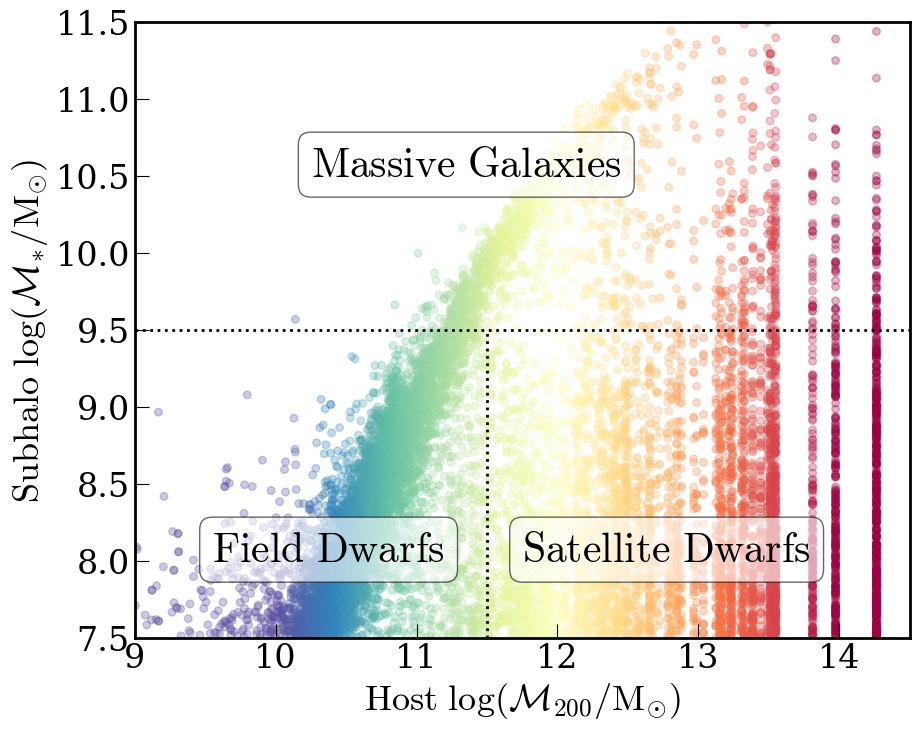

In [27]:
fig,ax=plt.subplots(figsize=(10,8))

ax.scatter(m200_a,mst_a,c=m200_a,cmap=mcm.Spectral_r,vmin=10,vmax=14,alpha=0.3,s=30)
#ax.scatter(m200_a[dw_samp],mst_a[dw_samp],c='none',edgecolors='black',marker='o',linewidth=0.5,alpha=0.3)

ax.set_xlim((9,14.5))
ax.set_ylim((7.5,11.5))
ax.axhline(9.5,ls=':',lw=2,color='black')
ax.axvline(11.5,ymax=0.5,ls=':',lw=2,color='black')

ax.text(10.25,10.5,r'$Massive\ Galaxies$',fontsize=30,bbox=dict(facecolor='white',alpha=0.6, boxstyle='round'))
ax.text(11.75,8,r'$Satellite\ Dwarfs$',fontsize=30,bbox=dict(facecolor='white',alpha=0.6, boxstyle='round'))
ax.text(9.55,8,r'$Field\ Dwarfs$',fontsize=30,bbox=dict(facecolor='white',alpha=0.6, boxstyle='round'))

ax.set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=26)
ax.set_ylabel(r'$Subhalo\ log(\mathcal{M}_{\ast}/M_{\odot})$',fontsize=26)
ax.set_rasterized(True)
#plt.savefig('hostM_subhaloM.pdf',bbox_inches='tight')

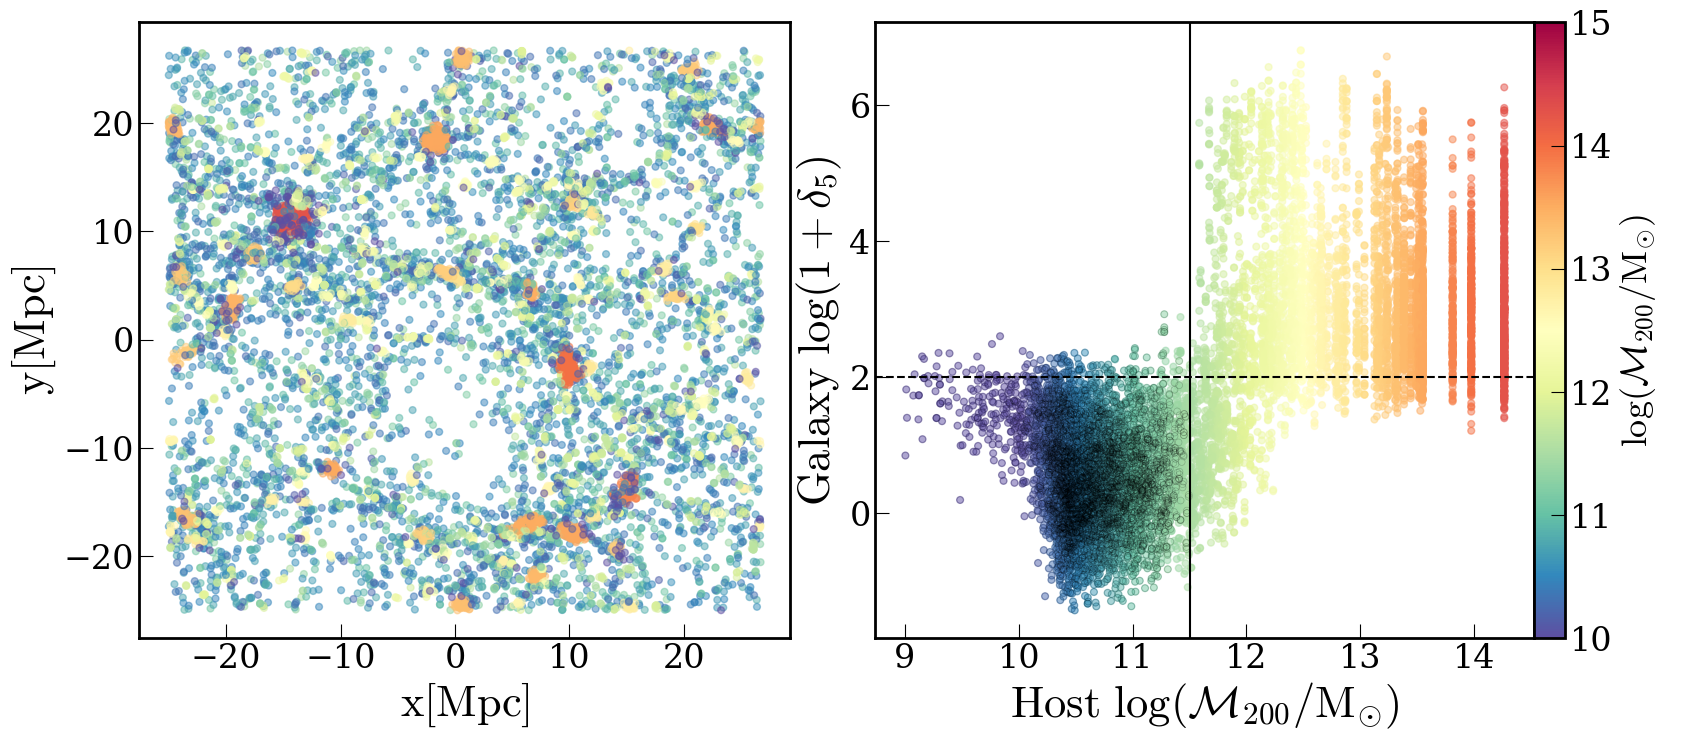

In [25]:
fig,ax=plt.subplots(1,4,figsize=(20,8),width_ratios=[0.42,0.055,0.50,0.025])
'''
gs = ax[0,0].get_gridspec()
ax[0,1].remove()
ax[0,0].remove()
axbig = fig.add_subplot(gs[0,:])

ax[1,0].scatter(dhost_a,llr_a,c=gls.hst.group_m200[llh_a],cmap=mcm.Spectral_r,vmin=10,vmax=14,alpha=0.5)
ax[1,1].scatter(llt_a,llr_a,c=gls.hst.group_m200[llh_a],cmap=mcm.Spectral_r,vmin=10,vmax=14,alpha=0.5)

#ax[1,0].scatter(dhost_a[dw_samp],llr_a[dw_samp],c='none',edgecolors='black',marker='o',linewidth=0.2,alpha=0.1)
#ax[1,1].scatter(llt_a[dw_samp],llr_a[dw_samp],c='none',edgecolors='black',marker='o',linewidth=0.2,alpha=0.1)

ax[1,0].axvline(1.5,color='black',ls='--')
ax[1,1].axvline(0,color='black',ls='--')

ax[1,0].set_xscale('log')
ax[1,1].invert_xaxis()
ax[1,1].set_xlim(left=6)
#ax.scatter(x_a[llg_int],y_a[llg_int],c='none',edgecolors='black',linewidth=2,alpha=0.8) 
#ax.scatter(x_a[ms_samp],y_a[ms_samp],marker='o',c='yellow',s=2,alpha=0.6)
'''
ax[1].set_axis_off()
ax[3].set_axis_off()

ax[0].scatter(x_a,y_a,marker='o',c=gls.hst.group_m200[llh_a],cmap=mcm.Spectral_r,vmin=10,vmax=15,alpha=0.5,s=24)

ax[0].set_xlabel(r'$x[Mpc]$',fontsize=32)
ax[0].set_ylabel(r'$y[Mpc]$',fontsize=32)

ax[2].scatter(m200_a,llr_a,c=m200_a,cmap=mcm.Spectral_r,vmin=10,vmax=15,alpha=0.5,s=24)
ax[2].scatter(m200_a[dw_samp],llr_a[dw_samp],c='none',edgecolors='black',marker='o',linewidth=0.5,alpha=0.2,s=24)

ax[2].axvline(11.5,color='black')
ax[2].axhline(2,color='black',ls='--')

ax[2].set_ylabel(r'$Galaxy\ log(1+\delta_5)$',fontsize=32)
ax[2].set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=32)

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=10, vmax=15),cmap=mcm.Spectral_r), ax=ax[2], orientation='vertical',label=r'$log(\mathcal{M}_{200}/M_{\odot})$',pad=0.0)

ax[0].set_rasterized(True)
ax[2].set_rasterized(True)
plt.subplots_adjust(wspace=0.0)
#plt.savefig('dens_map.pdf',bbox_inches='tight')


In [ ]:
fig,ax=plt.subplots(1,4,figsize=(25,10),width_ratios=[0.42,0.055,0.50,0.025])

for k in range(3):
    llt_b = np.array([t for t in llt[k]])
    llr_b = np.log10(np.array([r for r in llr[k]])) - np.log10(0.142904)
    
    ssfr_b = np.array([s for s in gls.sub.ssfr[llg[k]]])
    mst_b = np.array([m for m in gls.sub.mst[llg[k]]])
    sfms_b = ssfr_b-(sfms_intercept + sfms_slope*np.array(mst_b))

    x_b = np.array([x for x in gls.sub.SubhaloPos[llg[k],0]])*dconv - 25
    y_b = np.array([y for y in gls.sub.SubhaloPos[llg[k],1]])*dconv - 25

    llh_b = 10.155 + np.log10( np.array([gls.sub.SubhaloMass[h] for h in llg[k]]))

    ax[0].scatter(x_b,y_b,marker='o',c=sfms_b,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.5)
    ax[2].scatter(mst_b-llh_b,llr_b,c=sfms_b,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.5)

    if k==1:
        ax[0].scatter(x_b,y_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=1.5,alpha=0.5,s=80) 
        ax[2].scatter(mst_b-llh_b,llr_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=1.5,alpha=0.5,s=80) 

    if k==2:
        ax[0].scatter(x_b,y_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=2,s=80) 
        ax[2].scatter(mst_b-llh_b,llr_b,c='none',edgecolors='black',marker=bin_mk[k],linewidth=2,s=80)  
        


ax[0].set_xlabel(r'$x[Mpc]$',fontsize=32)
ax[0].set_ylabel(r'$y[Mpc]$',fontsize=32)


#ax[2].axvline(9.5,color='black')
ax[2].axhline(2,color='black',ls='--')

ax[2].set_ylabel(r'$Galaxy\ log(1+\delta_5)$',fontsize=32)
ax[2].set_xlabel(r'$Host\ log(\mathcal{M}_{\ast}/M_{\odot})$',fontsize=32)

ax[1].set_axis_off()
ax[3].set_axis_off()

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=10, vmax=15),cmap=mcm.Spectral_r), ax=ax[2], orientation='vertical',label=r'$log(\mathcal{M}_{200}/M_{\odot})$')

ax[0].set_rasterized(True)
ax[2].set_rasterized(True)
plt.subplots_adjust(wspace=0.05)
plt.savefig('special_env_dssfr.pdf',bbox_inches='tight')


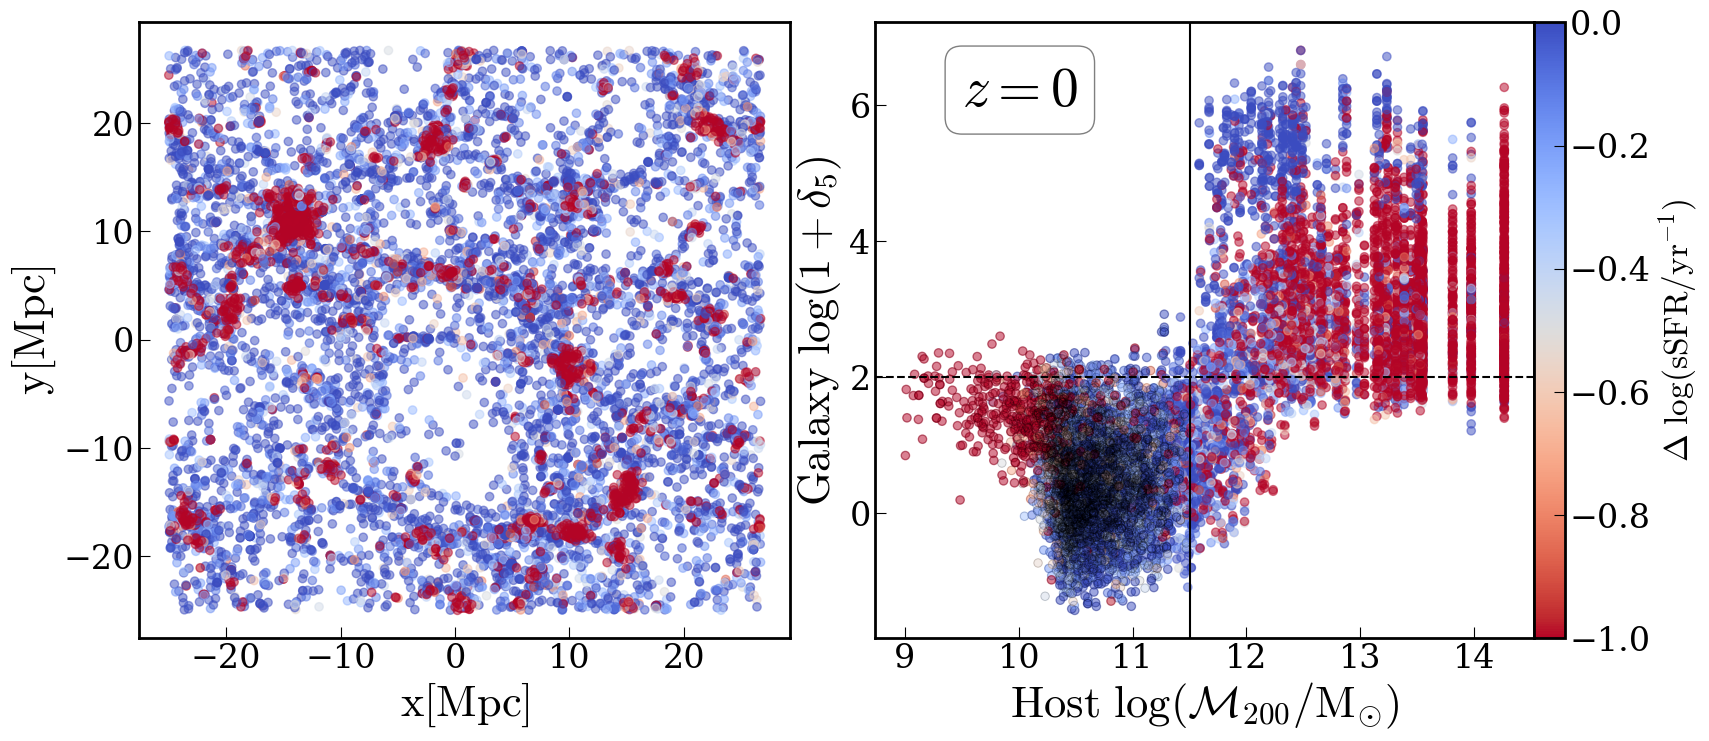

In [9]:
fig,ax=plt.subplots(1,4,figsize=(20,8),width_ratios=[0.42,0.055,0.50,0.025])

#mdyn_a = 10.155 + np.log10( np.array([gls.sub.SubhaloMass[h] for i in range(3) for h in llg[i]]))
qnc_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))
#mag_samp = np.where((mst_a<9.5)&(qnc_a>1))[0]
#mag_samp = np.where((mst_a<9.5)&(qnc_a<-1))[0]
#print(len(mag_samp))

ax[0].scatter(x_a,y_a,marker='o',c=qnc_a,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.5)

ax[0].set_xlabel(r'$x[Mpc]$',fontsize=32)
ax[0].set_ylabel(r'$y[Mpc]$',fontsize=32)

#ax[2].scatter(mst_a[mag_samp]-mdyn_a[mag_samp],llr_a[mag_samp],c=qnc_a[mag_samp],cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.5)
ax[2].scatter(m200_a,llr_a,c=qnc_a,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.5)
ax[2].scatter(m200_a[dw_samp],llr_a[dw_samp],c='none',edgecolors='black',marker='o',linewidth=0.5,alpha=0.2)

ax[2].axvline(11.5,color='black')
ax[2].axhline(2,color='black',ls='--')

ax[2].set_ylabel(r'$Galaxy\ log(1+\delta_5)$',fontsize=32)
ax[2].set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=32)
ax[2].text(9.5,6,r'${\it z=0}$',fontsize=40,bbox=dict(boxstyle='round',facecolor='white', alpha=0.5))

ax[1].set_axis_off()
ax[3].set_axis_off()

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax[2], orientation='vertical',label=r'$\Delta\ log(sSFR/yr^{-1})$',pad=0.0)

ax[0].set_rasterized(True)
ax[2].set_rasterized(True)
plt.subplots_adjust(wspace=0.0)
plt.savefig('dens_mapv2.pdf',bbox_inches='tight')


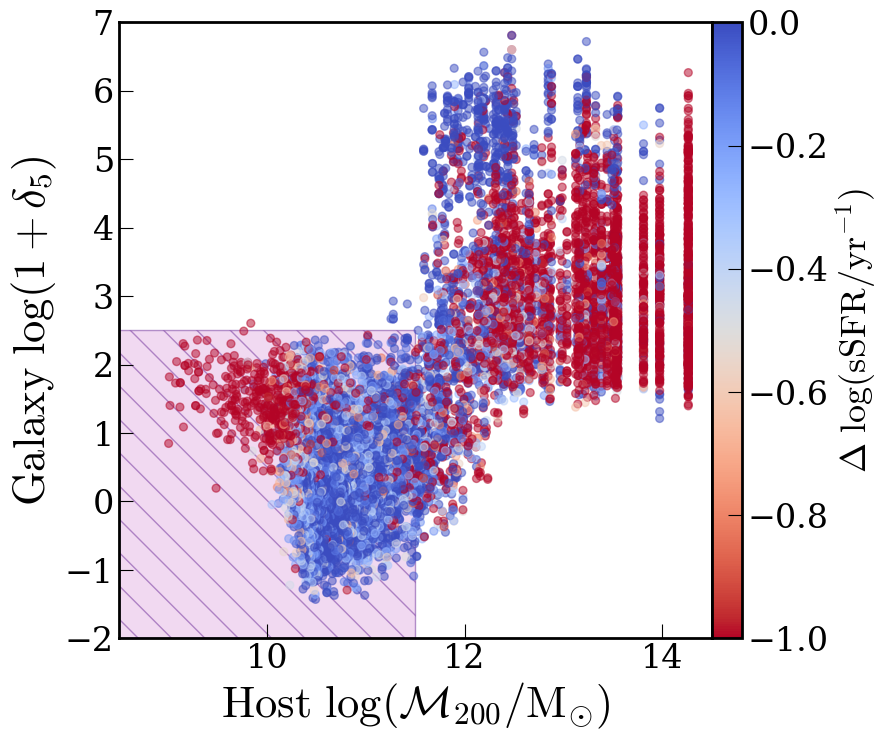

In [43]:
fig,ax=plt.subplots(figsize=(9,8))

#mdyn_a = 10.155 + np.log10( np.array([gls.sub.SubhaloMass[h] for i in range(3) for h in llg[i]]))
qnc_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))
#mag_samp = np.where((mst_a<9.5)&(qnc_a>1))[0]
#mag_samp = np.where((mst_a<9.5)&(qnc_a<-1))[0]
#print(len(mag_samp))

plt.fill_between(
    [8.5,11.5], -2, 2.5, 
    facecolor="plum",  # Background fill color (use "none" for transparent)
    edgecolor="indigo",       # Color of the hatch lines
    hatch="\\",             # Hatch pattern string
    alpha=0.4               # Transparency of the background fill
)

ax.scatter(m200_a,llr_a,c=qnc_a,cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.5,s=32)

ax.set_xlim((8.5,14.5))
ax.set_ylim((-2,7))
#ax.axvline(11.5,color='black')
#ax.axhline(2,color='black',ls='--')

ax.set_ylabel(r'$Galaxy\ log(1+\delta_5)$',fontsize=32)
ax.set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=32)
#ax.text(9.5,6,r'${\it z=0}$',fontsize=40,bbox=dict(boxstyle='round',facecolor='white', alpha=0.5))

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax, orientation='vertical',label=r'$\Delta\ log(sSFR/yr^{-1})$',pad=0.0)

ax.set_rasterized(True)
plt.subplots_adjust(wspace=0.0)
plt.savefig('dens_single.pdf',bbox_inches='tight')


In [15]:
qnc_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))

dw_samp = np.where((mst_a<9.5))[0]

print(len(dw_samp),len(np.where(qnc_a[dw_samp]>-1)[0]))

10848 7371


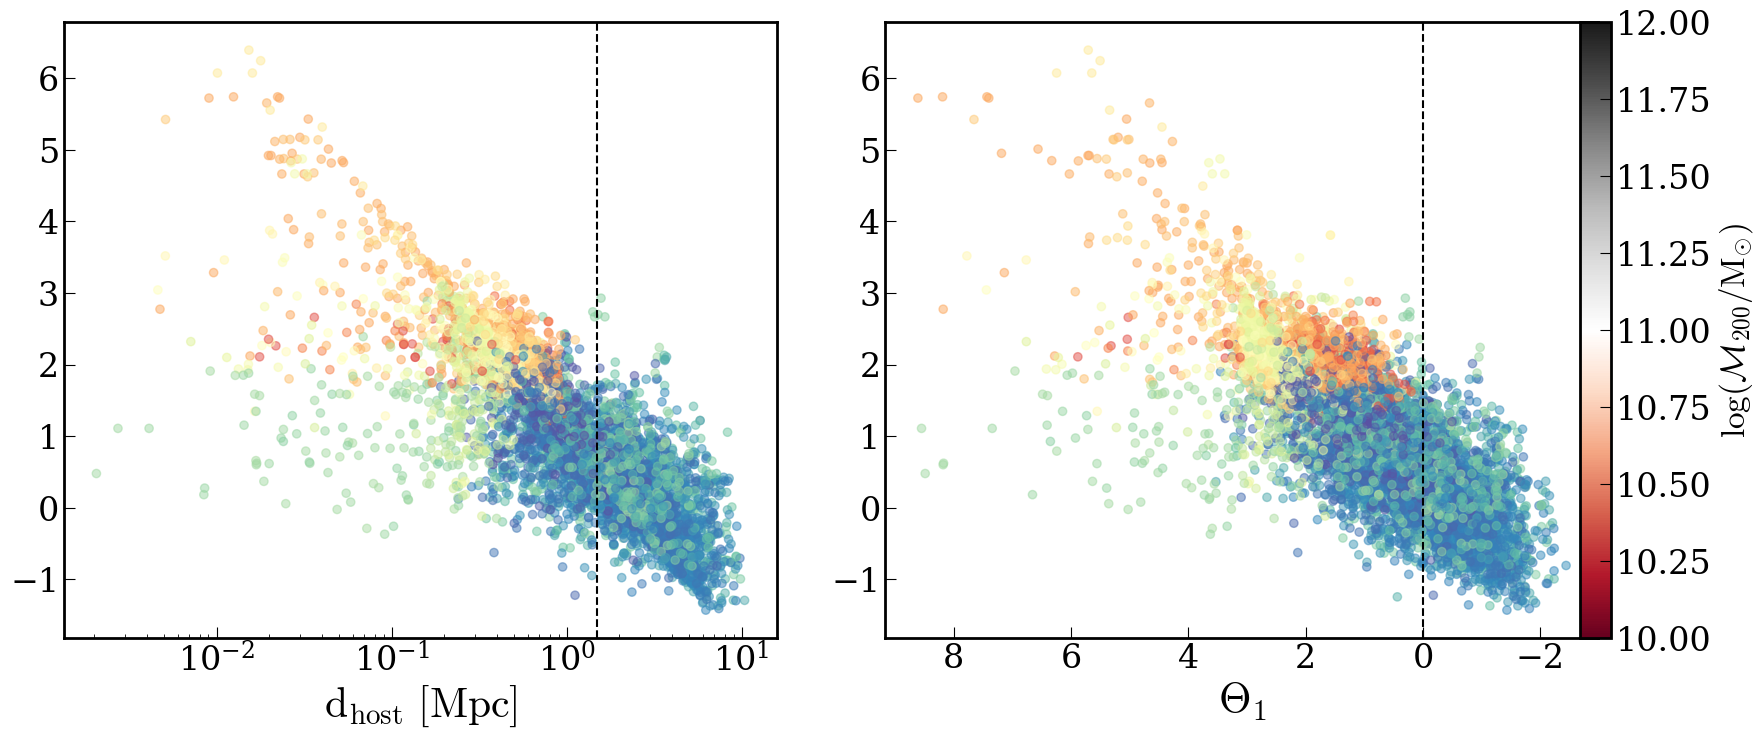

In [32]:
fig,ax=plt.subplots(1,4,figsize=(20,8),width_ratios=[0.46,0.07,0.46,0.01])

#dens_srt = np.sort(llr_a)
#print(dens_srt)
#den_scr = sts.percentileofscore(dens_srt,llr_a)

ax[0].scatter(dhost_a[dw_samp],llr_a[dw_samp],c=gls.hst.group_m200[llh_a[dw_samp]],cmap=mcm.Spectral_r,vmin=10,vmax=15,alpha=0.5)
ax[2].scatter(llt_a[dw_samp],llr_a[dw_samp],c=gls.hst.group_m200[llh_a[dw_samp]],cmap=mcm.Spectral_r,vmin=10,vmax=15,alpha=0.5)

#ax[0].set_xlim((7,9.5))
#ax[0].set_xlabel(r'$log(1+\delta_5)$',fontsize=30)
#ax[2].set_xlabel(r'$log(1+\delta_5)$',fontsize=30)
ax[2].set_xlabel(r'$\Theta_1$',fontsize=30)
ax[0].set_xlabel(r'$d_{host}\ [Mpc]$',fontsize=30)

ax[0].set_xscale('log')
ax[2].invert_xaxis()

ax[0].axvline(1.5,color='black',ls='--')
ax[2].axvline(0,color='black',ls='--')

ax[1].set_axis_off()
ax[3].set_axis_off()

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=10, vmax=12),cmap=mcm.RdGy), ax=ax[3], orientation='vertical',fraction=2.2,label=r'$log(\mathcal{M}_{200}/M_{\odot})$')
ax[0].set_rasterized(True)
ax[2].set_rasterized(True)
plt.subplots_adjust(wspace=0.0)
#plt.savefig('tidal_mst.pdf',bbox_inches='tight')

In [86]:
host_bins = [np.where((m200_a<11.5)|((m200_a>=11.5)&(x200_a>=1)))[0],np.where((m200_a>=11.5)&(x200_a<1))[0]]
host_outs =  np.where((m200_a>=11.5)&(x200_a>=1))[0]

1565


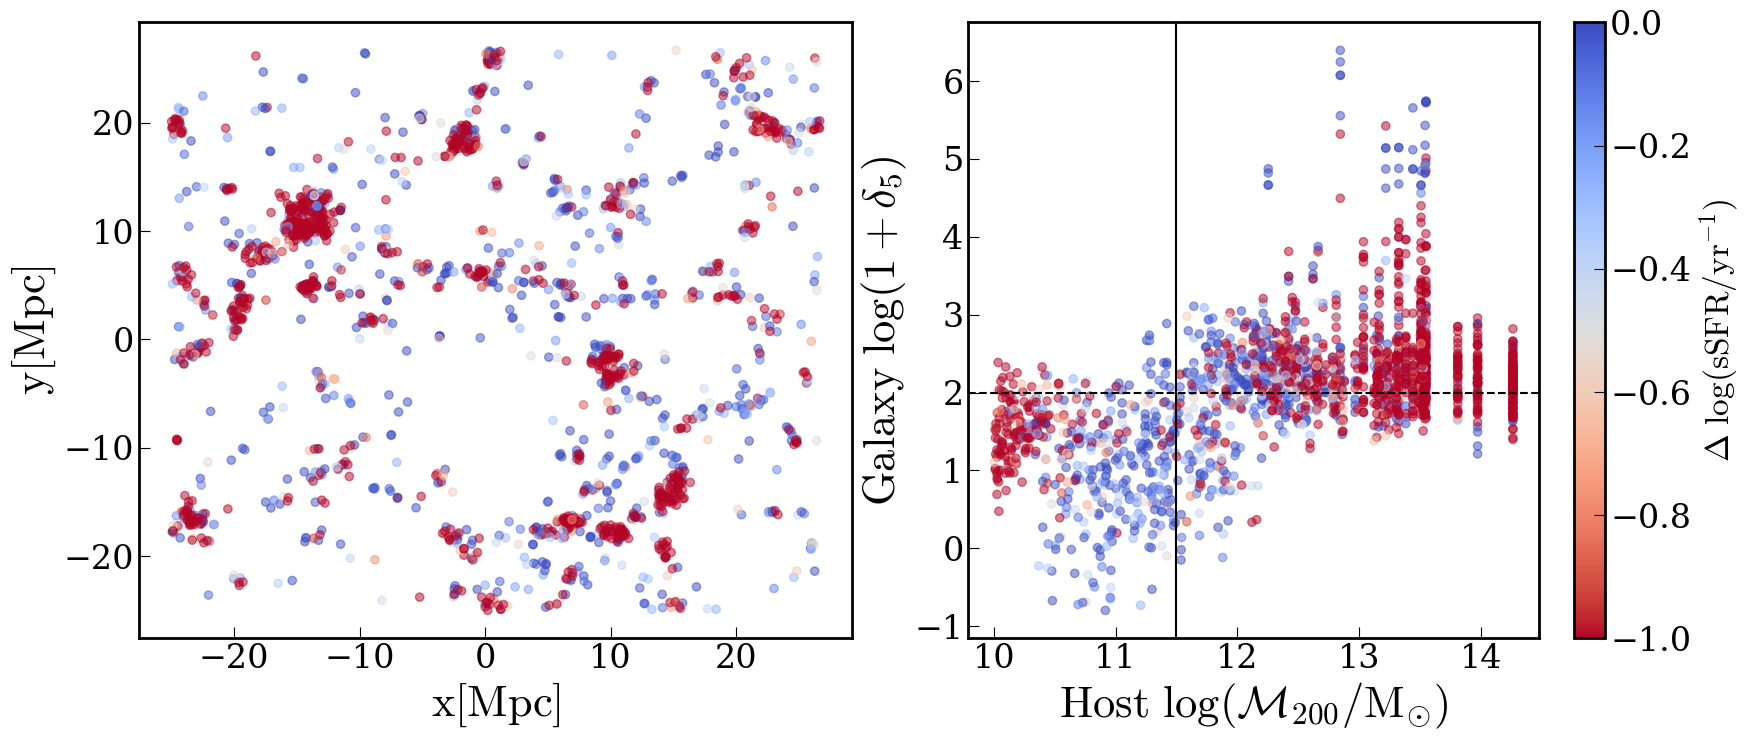

In [35]:
fig,ax=plt.subplots(1,4,figsize=(20,8),width_ratios=[0.46,0.075,0.46,0.005])

qnc_a = ssfr_a-(sfms_intercept + sfms_slope*np.array(mst_a))
#mag_samp = np.where((mst_a<9.5)&(qnc_a>1))[0]
#dhost_out = np.where((m200_a>=11.5)&(mst_a<9.5))[0]
print(len(dhost_out))

ax[0].scatter(x_a[dw_samp],y_a[dw_samp],marker='o',c=qnc_a[dw_samp],cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.5)

ax[0].set_xlabel(r'$x[Mpc]$',fontsize=32)
ax[0].set_ylabel(r'$y[Mpc]$',fontsize=32)

ax[2].scatter(m200_a[dw_samp],llr_a[dw_samp],c=qnc_a[dw_samp],cmap=mcm.coolwarm_r,vmin=-1, vmax=0,alpha=0.5)

#ax[2].scatter(m200_a[dw_samp],llr_a[dw_samp],c='none',edgecolors='black',marker='o',linewidth=0.5,alpha=0.2)

ax[2].axvline(11.5,color='black')
ax[2].axhline(2,color='black',ls='--')

ax[2].set_ylabel(r'$Galaxy\ log(1+\delta_5)$',fontsize=32)
ax[2].set_xlabel(r'$Host\ log(\mathcal{M}_{200}/M_{\odot})$',fontsize=32)

ax[1].set_axis_off()
ax[3].set_axis_off()

fig.colorbar(mcm.ScalarMappable(norm=mcol.Normalize(vmin=-1, vmax=0),cmap=mcm.coolwarm_r), ax=ax[2], orientation='vertical',label=r'$\Delta\ log(sSFR/yr^{-1})$')

ax[0].set_rasterized(True)
ax[2].set_rasterized(True)
plt.subplots_adjust(wspace=0.0)
#plt.savefig('dens_mapv2.pdf',bbox_inches='tight')

#plt.savefig('tidal_mst.pdf',bbox_inches='tight')




In [16]:
def lin_scale(x,vmin,vmax):
    y = (x-vmin)/(vmax-vmin)
    y[np.where(y>1)[0]] = 1
    y[np.where(y<0)[0]] = 0
    
    return y

In [17]:
print(min(dhost_a[dw_samp]),max(dhost_a[dw_samp]),np.median(dhost_a[dw_samp]))
print(min(llt_a[dw_samp]),max(llt_a[dw_samp]),np.median(llt_a[dw_samp]))

0.3349547310493402 15.955629200311522 2.55139927618192
-2.7864983518630275 2.7935069378801813 -0.1873183054571239
